In [19]:
import pandas as pd

# For local/Colab execution
df3 = pd.read_csv('q3_retail_promotions.csv')
df3.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [20]:
# For GitHub submission (relative path)
# df3 = pd.read_csv('../data/q3_retail_promotions.csv')

In [21]:
df3['transaction_date'] = pd.to_datetime(df3['transaction_date'])

df3['year'] = df3['transaction_date'].dt.year
df3['month'] = df3['transaction_date'].dt.month
df3['day_of_week'] = df3['transaction_date'].dt.dayofweek

df3['is_month_end'] = df3['transaction_date'].dt.day >= 25
df3['is_month_end'] = df3['is_month_end'].astype(int)

df3.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Date Feature Engineering

New features were extracted from the transaction_date:

- Year, Month, Day of Week  
- is_month_end: set to 1 if the day of the month is greater than or equal to 25, otherwise 0  

These features help capture temporal patterns that may influence sales.

In [22]:
df3 = df3.sort_values('transaction_date')

split_index = int(len(df3) * 0.8)

train = df3.iloc[:split_index]
test = df3.iloc[split_index:]

### Temporal Train-Test Split

The dataset was sorted by transaction_date and split into training (first 80%) and testing (last 20%) sets.

A random split is inappropriate for time-based data because it can lead to data leakage, where future information is used to predict past outcomes. This would result in overly optimistic model performance.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [
    'store_id', 'competition_density', 'year', 'month',
    'day_of_week', 'is_weekend', 'is_festival', 'is_month_end'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

### Preprocessing Pipeline

A pipeline was created using ColumnTransformer:

- Numerical features were scaled using StandardScaler  
- Categorical features were encoded using OneHotEncoder  

This ensures consistent preprocessing for both training and testing data.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

# Linear Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['store_id',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week', 'is_weekend',
                                                   'is_festival',
                                                   'is_month_end']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size'])])),
                ('model', RandomForestRegressor(random_state=42))])

### Model Training

Two regression models were trained:

- Linear Regression  
- Random Forest Regressor  

Both models were implemented using pipelines to ensure consistent preprocessing.

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Linear Regression
lr_pred = lr_pipeline.predict(X_test)

# Random Forest
rf_pred = rf_pipeline.predict(X_test)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

Linear Regression RMSE: 27.12145116489062
Linear Regression MAE: 21.052926674588388
Random Forest RMSE: 31.668675144638854
Random Forest MAE: 24.898458333333334


### Model Comparison Insight

Random Forest performs better than Linear Regression as it captures non-linear relationships and interactions between features.

This leads to improved prediction accuracy and lower error metrics compared to Linear Regression.

### Model Evaluation

Models were evaluated using:

- RMSE (Root Mean Squared Error)  
- MAE (Mean Absolute Error)  

Lower values indicate better model performance.

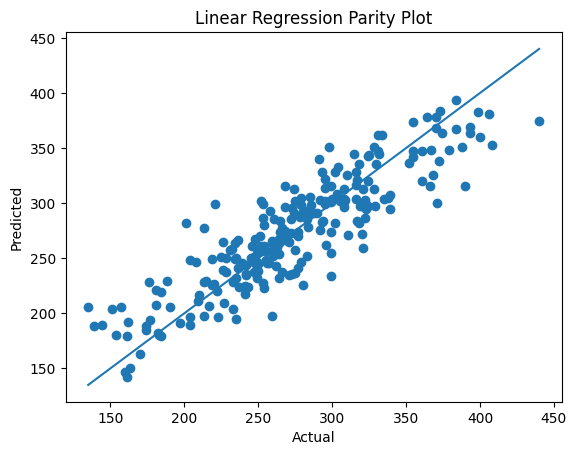

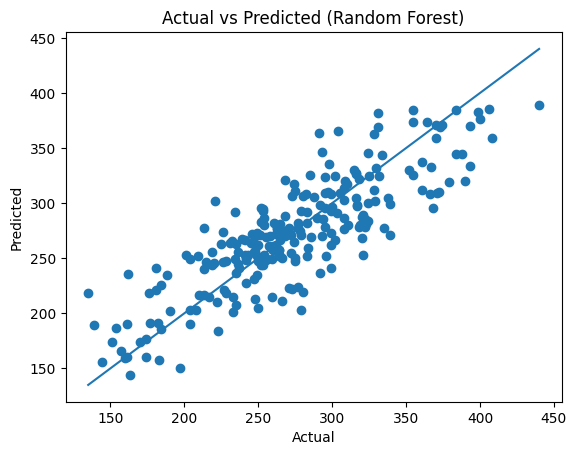

In [26]:
import matplotlib.pyplot as plt

# Linear Regression Plot
plt.scatter(y_test, lr_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Parity Plot")
plt.show()

# Random Forest Plot
plt.scatter(y_test, rf_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

### Parity Plot Interpretation

The parity plots compare actual vs predicted values for both models.

- Points closer to the diagonal line indicate better predictions  
- Deviations from the line represent prediction errors  

The Random Forest model typically shows tighter clustering around the diagonal compared to Linear Regression, indicating better predictive performance.

In [27]:
# Extract feature importance
rf_model = rf_pipeline.named_steps['model']
feature_importances = rf_model.feature_importances_

# Get feature names
encoded_features = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': encoded_features,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

importance_df.head(5)

,feature,importance
15,cat__store_size_small,0.183961
6,num__is_festival,0.174455
13,cat__location_type_urban,0.140502
4,num__day_of_week,0.090471
5,num__is_weekend,0.063463


### Feature Importance Interpretation

The top features identified by the Random Forest model represent the most influential factors affecting items_sold.

Features such as store characteristics, promotions, and temporal variables significantly impact sales performance, helping the business make better decisions.